# GuitarMidi-LV2 Library
 # Copyright (C) 2026 Gerald Mwangi
 #
 # This program is free software; you can redistribute it and/or
 # modify it under the terms of the GNU Lesser General Public
 # License as published by the Free Software Foundation; either
 # version 2 of the License, or (at your option) any later version.
 #
 # This program is distributed in the hope that it will be useful,
 # but WITHOUT ANY WARRANTY; without even the implied warranty of
 # MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU
 # Lesser General Public License for more details.
 #
 # You should have received a copy of the GNU Lesser General
 # Public License along with this program; if not, write to the
 # Free Software Foundation, Inc., 51 Franklin Street, Fifth Floor,
 # Boston, MA  02110-1301  USA

# description: This script creates a training subset of the GuitarMidi-LV2 dataset by filtering the TFRecord files based on polyphony and chord suffix count. It reads the input TFRecord files, applies filtering criteria, and writes the filtered data to a new TFRecord file.
#  The script also generates histograms of MIDI note occurrences and chord suffix distributions for analysis.

In [1]:
# description: This script creates a training subset of the GuitarMidi-LV2 dataset by filtering the TFRecord files based on polyphony and chord suffix count. It reads the input TFRecord files, applies filtering criteria, and writes the filtered data to a new TFRecord file.
#  The script also generates histograms of MIDI note occurrences and chord suffix distributions for analysis.

import time
import datetime
import numpy as np
import os,glob
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from common import OUTPUT_DIM_NOTES,SAMPLERATE,INPUT_SHAPE,Q_FACTOR,FRAME_LAG,plot_histogram,count_midi_notes
import soundfile as sf
from fretboardnonredundant import FretBoard
from pathlib import Path
from write_tfrecord_parallel import write_tfrecord_parallel
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

#training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'
training_dir='/data2/data_slices'
#subset = '/data/training_subset'
subset='/data2/training_subset_electric'
input_filepaths = sorted(glob.glob(os.path.join(training_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)
# input_filepaths=input_filepaths[:1000]

numfiles=len(input_filepaths)#500#18000#3426

numfiles=min(numfiles,len(input_filepaths))
print("Loading a fixed set of ",numfiles," files")# Amount to ~1GB on disk without filtering or 312GB with prefiltering
input_filepaths=input_filepaths[:numfiles]
feature_description = {
        "audio_path": tf.io.FixedLenFeature([], tf.string),
        "frame_nr":   tf.io.FixedLenFeature([], tf.int64),
        "output":     tf.io.FixedLenFeature([], tf.string),
    }


print(f'Number of input files: {len(input_filepaths)}')

# tf.py_function that creates a histogram of MIDI note occurrences from the label data in the TFRecord files
def createhist(labels):
    hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    output_data = labels.numpy()  # Reshape to (num_frames, 89)
    for note in range(OUTPUT_DIM_NOTES):
        if output_data[note] == 1:
            hist[note] += 1
    return hist

# Read the label data from the TFRecord files and create a histogram of MIDI note occurrences
def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    audio = parsed["audio_path"]
    label = tf.io.decode_raw(parsed["output"], tf.int8)
    # hist = tf.py_function(createhist, [label], tf.int32)
    return audio,label

def create_dataset_old(filepaths):
    dataset = tf.data.TFRecordDataset(filepaths)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE,use_unbounded_threadpool=True,deterministic=False)
    dataset=dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def count_midi_notes_old(dataset):
    # hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    initial_state = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    # 2. Define the reduction function
    # 'old_state' is the current sum, 'next_element' is (features, labels)
    def reduce_fn(old_state, next_element):
        _, labels = next_element
        # Cast labels to int32 to match state and prevent overflow
        return old_state + tf.cast(labels, tf.int32)

    # 3. Perform the reduction
    # This happens in the TF graph and is memory-efficient
    hist = dataset.reduce(initial_state, reduce_fn)
    
    return hist.numpy()
    # Parse the entire batch at once (Vectorized Parsing)
def parse_batch(serialized_batch):
        # Note: feature_description stays the same, but we use parse_example
    parsed = tf.io.parse_example(serialized_batch, feature_description)
        # No need for decode_raw if your data is stored as float/int in the proto, 
        # but if it is bytes, decode_raw works on the whole batch dimension too.
    # audio = tf.io.decode_raw(parsed["audio_path"], tf.string)
    #decode the audio path as string
    audio_path = parsed["audio_path"]
    #print type and value of audio_path
    # print("Audio path type:", audio_path.dtype)
    # print("Audio path value:", audio_path)
    frame_nr = parsed["frame_nr"]

    label = tf.io.decode_raw(parsed["output"], tf.int8)
    return audio_path,frame_nr, label


def create_dataset(filepaths, batch_size=256):
    # Convert file list to a dataset of strings
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    
    # Read from multiple files in parallel
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )
    
    # Batch the RAW serialized protos FIRST
    dataset = dataset.batch(batch_size)
    

    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.prefetch(tf.data.AUTOTUNE)



def create_balanced_dataset(filepaths, note_count_max, batch_size=256):
    # 1. Start with the RAW strings (Parallel I/O)
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )
    
    # 2. Vectorized Parsing (The "Turbo" Step)
    # We batch the raw strings, parse them as a block, then unbatch to filter
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.unbatch().prefetch(tf.data.AUTOTUNE)  # Back to individual (audio, label) pairs
    
    # 3. Stateful Filter Logic
    initial_hist = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    def scan_fn(running_hist, element):
        audio,frame_nr, labels = element
        labels_int = tf.cast(labels, tf.int32)
        
        # Identify counts of notes present in this sample (where label == 1)
        # If labels is [0, 1, 1] and hist is [500, 10, 1000], active_counts is [10, 1000]
        active_counts = tf.boolean_mask(running_hist, labels_int > 0)
        
        # "Only keep if the active note with the LEAST count is under the limit"
        # We use tf.reduce_min to find that smallest bin value.
        # If the sample is empty (no notes), we'll default to False to avoid noise.
        has_notes = tf.reduce_any(labels_int > 0)
        min_active_count = tf.reduce_min(active_counts) if has_notes else note_count_max
        
        can_keep = has_notes & (min_active_count < note_count_max)
        
        # Update histogram: only add labels if we decided to keep the sample
        new_hist = tf.where(can_keep, running_hist + labels_int, running_hist)
        
        return new_hist, (audio,frame_nr, labels, can_keep)

    # Apply scan and filter out the 'False' results
    dataset = dataset.scan(initial_state=initial_hist, scan_func=scan_fn)
    dataset = dataset.filter(lambda a,fnr, l, keep: keep)
    dataset = dataset.shuffle(buffer_size=20000, reshuffle_each_iteration=True)
    
    # 4. Final Polish
    # Remove the 'keep' boolean, re-batch for training, and prefetch
    dataset = dataset.map(lambda a,fnr, l, k: (a,fnr, l), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Fast label-only parser (no prints, no audio_path parsing overhead)
label_only_desc = {
    "audio_path": tf.io.FixedLenFeature([], tf.string),
    "frame_nr":   tf.io.FixedLenFeature([], tf.int64),
    "output":     tf.io.FixedLenFeature([], tf.string),
}

def parse_batch_fast(serialized_batch):
    parsed = tf.io.parse_example(serialized_batch, label_only_desc)
    audio_path = parsed["audio_path"]
    frame_nr   = parsed["frame_nr"]
    label      = tf.io.decode_raw(parsed["output"], tf.int8)
    return audio_path, frame_nr, label

def create_balanced_dataset_poly(filepaths, note_max, poly_max,max_active_notes=6, batch_size=256):
    # 1. Parallel I/O
    dataset=create_dataset(input_filepaths,batch_size=batch_size)

    return filter_polyphony_dataset(dataset, note_max, poly_max, max_active_notes=max_active_notes, batch_size=batch_size)

def filter_polyphony_dataset(dataset,note_max, poly_max,max_active_notes=6, batch_size=256):

    dataset = dataset.unbatch().prefetch(tf.data.AUTOTUNE)  # Back to individual (audio, label) pairs
    # 3. Stateful scan (unavoidably sequential, but keep it lean)
    initial_state = (
        tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32),  # note histogram
        tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32),  # poly histogram
    )

    def prefilter(audio,frame_nr,labels):
        labels_int = tf.cast(labels, tf.int32)

        num_active_silent = tf.reduce_sum(labels_int)
        return (num_active_silent > 0) & (num_active_silent<=(max_active_notes+1)) # only allow up to max_active_notes and the silence note
    dataset=dataset.filter(prefilter)

    def combined_scan_fn(state, element):
        note_hist, poly_hist = state
        audio, frame_nr, labels = element
        labels_int = tf.cast(labels, tf.int32)

        num_active = tf.reduce_sum(labels_int[:(OUTPUT_DIM_NOTES-1)])
        poly_idx   = tf.minimum(num_active, OUTPUT_DIM_NOTES - 1)

        # Polyphony check
        keep_poly = tf.gather(poly_hist, poly_idx) < poly_max

        # Note frequency check — avoid boolean_mask (dynamic shape, slow)
        # Instead: mask counts, find min among active notes only
        active_mask   = labels_int > 0
        masked_counts = tf.where(active_mask, note_hist, tf.fill([OUTPUT_DIM_NOTES], note_max))
        min_note_count = tf.reduce_min(masked_counts)
        keep_note = min_note_count < note_max

        can_keep = keep_poly & keep_note# & (num_active > 0) & (num_active<=(max_active_notes+1))

        # Update note histogram
        new_note_hist = tf.cond(
            can_keep,
            lambda: note_hist + labels_int,
            lambda: note_hist
        )

        # Update poly histogram
        poly_update   = tf.one_hot(poly_idx, depth=OUTPUT_DIM_NOTES, dtype=tf.int32)
        new_poly_hist = tf.cond(
            can_keep,
            lambda: poly_hist + poly_update,
            lambda: poly_hist
        )

        return (new_note_hist, new_poly_hist), (audio, frame_nr, labels, can_keep)

    dataset = dataset.scan(initial_state=initial_state, scan_func=combined_scan_fn)

    # 4. Filter, THEN shuffle (smaller buffer since already filtered)
    dataset = (
        dataset
        .filter(lambda a, fnr, l, keep: keep)
        .map(lambda a, fnr, l, k: (a, fnr, l))
        .shuffle(buffer_size=5000, reshuffle_each_iteration=True)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return dataset

def filter_notes(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels

        for note in range(OUTPUT_DIM_NOTES):
            hist[note]+=labels[note]
            # if labels[note] == 1:
            #     if hist[note] >= note_count_maximum: 
            #         result=False
        # assert labels[OUTPUT_DIM_NOTES-1]==0
        
        # Check the minimum count for notes that are present in the current sample
        masks = labels == 1
        #print("Mask for current sample:", masks)
        min_count = np.min(hist[masks]) if np.any(masks) else 0
        # print("Current histogram:", hist)
        # print("Min count for current sample:", min_count)
        # if min_count>0:
        #     print("Minimum count for notes with occurrences:", min_count)
        if min_count >= note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function

def filter_polyphony(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels
        num_active_notes=np.sum(labels[:(OUTPUT_DIM_NOTES-1)])
        if num_active_notes>=hist.shape[0]:  
            print("Warning: num_active_notes exceeds histogram size. This should not happen. num_active_notes:", num_active_notes, "histogram size:", hist.shape[0])
            return False        

        if hist[num_active_notes] > note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        else:
            hist[num_active_notes]+=1
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function






I0000 00:00:1785172756.816860   11844 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785172757.269068   11844 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785172758.263235   11844 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading a fixed set of  61376  files
Number of input files: 61376


# Polyphony analysis

This block analyzes the data and generates a histogram over the amount of concurrency in the data

Script started at: 2026-07-27 19:24:04.786716
Dataset created, counting MIDI notes...
This may take a while...


W0000 00:00:1785173045.756814   11844 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1785173045.760963   11844 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1785173045.844256   11844 gpu_device.cc:2040] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12803 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a
I0000 00:00:1785173046.017224   23194 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Histogram of concurrent notes in the filtered dataset: [331120427 326180925 123537177 123061608  57425720  37210087  35923351
    426638    268912    152692     73634     28394     19434         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0         0         0         0         0         0
         0         0  

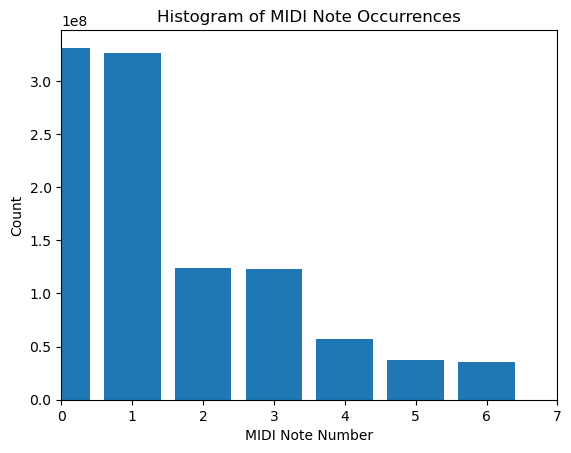

Script finished at: 2026-07-27 20:30:19.402335


In [2]:
#plot the histogram of concurrent notes in the dataset
write_block = True
plot_block = True
#print the time when the script started
from common import count_concurrent_notes_distribution,filter_polyphony
print("Script started at:", datetime.datetime.now())

# Load the filtered dataset and create a histogram over the number of concurrent notes in the labels

if plot_block:
    dataset = create_dataset(input_filepaths)
    print("Dataset created, counting MIDI notes...")
    print("This may take a while...")
    concurrent_notes_histogram = count_concurrent_notes_distribution(dataset,has_filtered_audio=False)
    print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
    plot_histogram(concurrent_notes_histogram[:7],7)

print("Script finished at:", datetime.datetime.now())




# Harmonic chord analysis

This block analyses the data filtered and capped by polyphony and outputs the histogram over the different chord suffixes

Script started at: 2026-07-27 20:30:19.407010
Building pitch-class -> suffix lookup table (one-time cost)...
Lookup table built: 12288 entries.


I0000 00:00:1785180355.401364   11844 local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total frames:            1035428999
Skipped (silent):        325672169
Skipped (note count):    8058503
Skipped (unrecognized):  5106172
Chords counted:          696592155
single_note     337470738  (48.45%)
major           219889676  (31.57%)
minor           44474534  ( 6.38%)
sus4            29998930  ( 4.31%)
sus2            12513986  ( 1.80%)
minor7          11215249  ( 1.61%)
dominant7        6744216  ( 0.97%)
major6           5741743  ( 0.82%)
major7           5362956  ( 0.77%)
diminished       4160558  ( 0.60%)
add9             3698303  ( 0.53%)
augmented        3616041  ( 0.52%)
7b9              2881287  ( 0.41%)
sus4_7           2099364  ( 0.30%)
major9           1466526  ( 0.21%)
sus2_7            957555  ( 0.14%)
9                 932726  ( 0.13%)
minor7b5          868879  ( 0.12%)
minorAdd9         716851  ( 0.10%)
minor9            563040  ( 0.08%)
7#9               519422  ( 0.07%)
diminished7       270384  ( 0.04%)
minor6            265350  ( 0.04%)
minorMajor7       163

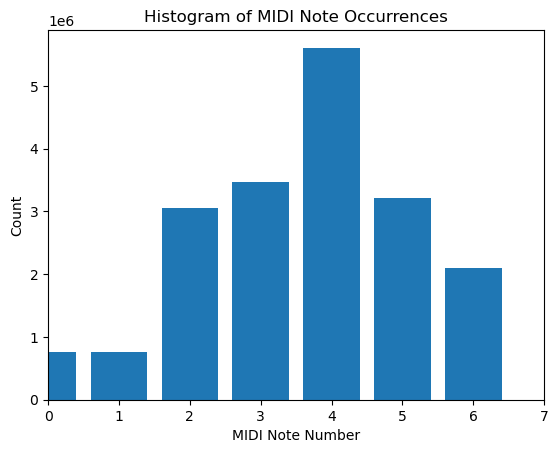

Building pitch-class -> suffix lookup table (one-time cost)...
Lookup table built: 12288 entries.


I0000 00:00:1785197521.052816   11844 local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total frames:            18980536
Skipped (silent):        769858
Skipped (note count):    0
Skipped (unrecognized):  767162
Chords counted:          17443516
major            1345691  ( 7.71%)
minor7           1239674  ( 7.11%)
7b9              1091453  ( 6.26%)
sus4              992503  ( 5.69%)
minor7b5          868879  ( 4.98%)
single_note       826583  ( 4.74%)
add9              791889  ( 4.54%)
major7            767180  ( 4.40%)
sus4_7            767177  ( 4.40%)
diminished        767167  ( 4.40%)
minor             767144  ( 4.40%)
augmented         767130  ( 4.40%)
major9            767123  ( 4.40%)
9                 767117  ( 4.40%)
sus2_7            742384  ( 4.26%)
minorAdd9         716851  ( 4.11%)
sus2              668549  ( 3.83%)
minor9            563040  ( 3.23%)
major6            551592  ( 3.16%)
dominant7         510125  ( 2.92%)
7#9               464690  ( 2.66%)
diminished7       270384  ( 1.55%)
minor6            265350  ( 1.52%)
minorMajor7       163841  ( 0.94%)
H

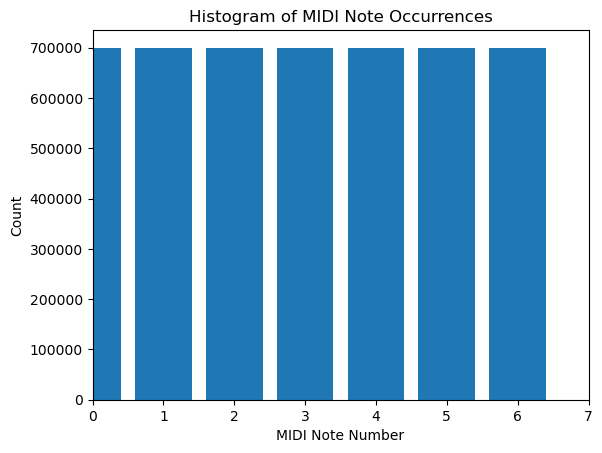

Building pitch-class -> suffix lookup table (one-time cost)...
Lookup table built: 12288 entries.
Total frames:            4900000
Skipped (silent):        703669
Skipped (note count):    0
Skipped (unrecognized):  127684
Chords counted:          4068647
major            1326103  (32.59%)
single_note       759783  (18.67%)
minor             577356  (14.19%)
sus4              219530  ( 5.40%)
minor7            199988  ( 4.92%)
sus2              174616  ( 4.29%)
dominant7         169741  ( 4.17%)
add9              106856  ( 2.63%)
major7            103376  ( 2.54%)
major6             86928  ( 2.14%)
sus4_7             63341  ( 1.56%)
major9             58881  ( 1.45%)
augmented          36110  ( 0.89%)
7b9                30048  ( 0.74%)
diminished         28890  ( 0.71%)
sus2_7             24678  ( 0.61%)
9                  19575  ( 0.48%)
minorAdd9          18198  ( 0.45%)
minor6             14451  ( 0.36%)
minor9             13914  ( 0.34%)
minor7b5           13904  ( 0.34%)
7#9       

In [3]:
# print the histogram of chord suffixes in the dataset, first filter by polyphony and then by chord suffix count
print("Script started at:", datetime.datetime.now())

from tffilters.chordfilter import create_balanced_dataset_chords
from guitarchordanalyzer import GuitarChordAnalyzer, CHORD_FORMULAS
from chordanalysishistogram import build_chord_suffix_histogram_fast, print_histogram
from common import count_concurrent_notes_distribution
# chord analysis
#dataset = create_dataset(input_filepaths)
note_count_maximum =int( 2e9) #unrealistically high, just to avoid filtering by note count. notes are weighted during training, so we don't need to filter by note count. We only want to filter by polyphony.
poly_count_maximum =int(0.7e6)# 0.4e8
chord_filtering=int(767117)
dataset=create_dataset(input_filepaths)
#----------------------------------------------
# print histograms for chord and polyphony distributions

histogram = build_chord_suffix_histogram_fast(dataset, GuitarChordAnalyzer)
print_histogram(histogram, top_n=30)

# concurrent_notes_histogram = count_concurrent_notes_distribution(dataset,has_filtered_audio=False)
# print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
# plot_histogram(concurrent_notes_histogram[:7],7)

#---------------------------------------------

# filter by chords
filtered_chord=create_balanced_dataset_chords(dataset,chord_filtering)

# print histograms
concurrent_notes_histogram = count_concurrent_notes_distribution(filtered_chord,has_filtered_audio=False)
print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
plot_histogram(concurrent_notes_histogram[:7],7)
histogram = build_chord_suffix_histogram_fast(filtered_chord, GuitarChordAnalyzer)
print_histogram(histogram, top_n=30)

#--------------------
# filter by polyphony
filtered_poly=filter_polyphony_dataset(filtered_chord,note_max=note_count_maximum,poly_max=poly_count_maximum)

# print histograms
concurrent_notes_histogram = count_concurrent_notes_distribution(filtered_poly,has_filtered_audio=False)
print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
plot_histogram(concurrent_notes_histogram[:7],7)
histogram = build_chord_suffix_histogram_fast(filtered_poly, GuitarChordAnalyzer)
print_histogram(histogram, top_n=30)

print("Script finished at:", datetime.datetime.now())


# Generation prefiltered audio
This code filters the data by polyphony and chord suffixes, evening out the distribution over both variables and writes the filtered data to disk.
Thereby it generates the filtered audio using the filterbank

Script started at: 2026-07-28 07:01:56.276205
Building pitch-class -> suffix lookup table (one-time cost)...
Lookup table built: 12288 entries.


I0000 00:00:1785226006.345061   11844 local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total frames:            254278119
Skipped (silent):        40207528
Skipped (note count):    0
Skipped (unrecognized):  4910588
Chords counted:          209160003
major           77647247  (37.12%)
single_note     43100885  (20.61%)
minor           32260886  (15.42%)
sus4            10161309  ( 4.86%)
minor7           8400953  ( 4.02%)
sus2             7584815  ( 3.63%)
dominant7        6020499  ( 2.88%)
major7           4065892  ( 1.94%)
add9             3539716  ( 1.69%)
major6           3148550  ( 1.51%)
sus4_7           2056827  ( 0.98%)
diminished       1950024  ( 0.93%)
augmented        1692627  ( 0.81%)
7b9              1488207  ( 0.71%)
major9           1362581  ( 0.65%)
9                 902965  ( 0.43%)
sus2_7            795939  ( 0.38%)
minor7b5          663829  ( 0.32%)
minorAdd9         628389  ( 0.30%)
minor9            548187  ( 0.26%)
7#9               470823  ( 0.23%)
minor6            260213  ( 0.12%)
diminished7       260101  ( 0.12%)
minorMajor7       148539  ( 0.0

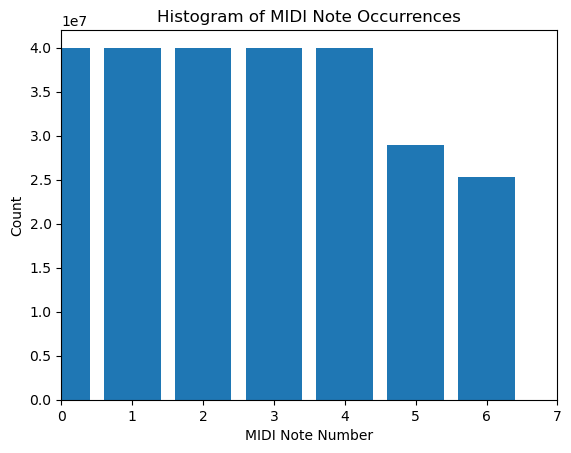

Histogram of MIDI notes in the polyphony-filtered dataset: [       0        0        0        0        0        0        0        0
        0        0        0        0        0        0        0        0
        0        0        0        0        0        0        0        0
        0        0        0        0     9517     2247     5923     1144
     4029    39718    53248   293010   783909   863378  3149119  2666375
 18088548  6583376  7511005 14995908  6317849 30775201  7533958 27836599
 20016091 12115304 38886911 10007781 44975654 15203916 20072468 42926496
 16363320 48326221 12985933 43327480 31934928 20864899 38139430 11540317
 46867219 14810585 19775737 19319107  6841787 11675049  3017509  6299918
  3404121  1723115  2600275   788008  1904543   453961   487141   546526
   184571   353395    70767   193818    79170    31311    40464    15348
    23681     3272     2376      242     2029      114      590        0
        0        0        0        0        0        0        0  

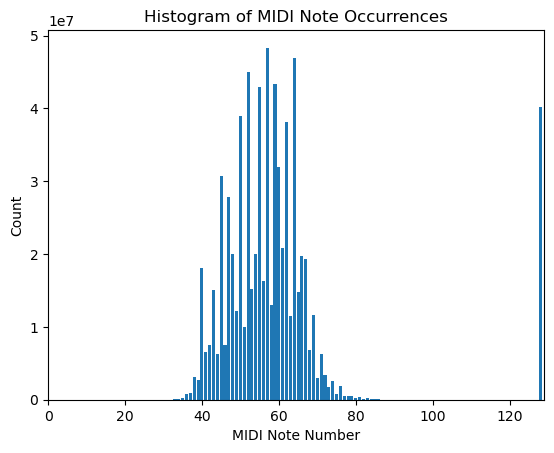

Writing polyphony-filtered dataset to TFRecord: /data2/training_subset_electric/filtered_poly_data
Write parallel using 29 workers
5000 protos queued ...
10000 protos queued ...
15000 protos queued ...
20000 protos queued ...
25000 protos queued ...
30000 protos queued ...
35000 protos queued ...
40000 protos queued ...
45000 protos queued ...
50000 protos queued ...
55000 protos queued ...
60000 protos queued ...
65000 protos queued ...
70000 protos queued ...
75000 protos queued ...
80000 protos queued ...
85000 protos queued ...
90000 protos queued ...
95000 protos queued ...
100000 protos queued ...
105000 protos queued ...
110000 protos queued ...
115000 protos queued ...
120000 protos queued ...
125000 protos queued ...
130000 protos queued ...
135000 protos queued ...
140000 protos queued ...
145000 protos queued ...
150000 protos queued ...
155000 protos queued ...
160000 protos queued ...
165000 protos queued ...
170000 protos queued ...
175000 protos queued ...
180000 protos 

In [ ]:
#Filter the dataset by chord suffix count and polyphony, and write the filtered dataset to a new TFRecord file
write_block = True
note_count_maximum = 2e9 #unrealistically high, just to avoid filtering by note count. notes are weighted during training, so we don't need to filter by note count. We only want to filter by polyphony.
poly_count_maximum = 0.4e8
chord_count_maximum = 44474534# maximum number of frames per chord suffix bucket
from tffilters.chordfilter import create_balanced_dataset_chords
from guitarchordanalyzer import GuitarChordAnalyzer, CHORD_FORMULAS
from chordanalysishistogram import build_chord_suffix_histogram_fast, print_histogram
print("Script started at:", datetime.datetime.now())



dataset=create_dataset(input_filepaths)
#filtered_poly_dschord=create_balanced_dataset_poly(input_filepaths, note_max=int(note_count_maximum), poly_max=int(poly_count_maximum), batch_size=256)
filtered_poly_dschord=create_balanced_dataset_chords(dataset=dataset, max_labels=int(chord_count_maximum), batch_size=256, max_active_notes=6)


filtered_poly_dschord=filter_polyphony_dataset(filtered_poly_dschord,int(note_count_maximum),int(poly_count_maximum))
histogram = build_chord_suffix_histogram_fast(filtered_poly_dschord, GuitarChordAnalyzer)
print_histogram(histogram, top_n=30)


concurrent_notes_histogram = count_concurrent_notes_distribution(filtered_poly_dschord,has_filtered_audio=False)
print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
plot_histogram(concurrent_notes_histogram[:7],7)
# Load the filtered dataset and create a histogram over the number of concurrent notes in the labels

Path(subset).mkdir(parents=True,exist_ok=True)
notes_histo=count_midi_notes(filtered_poly_dschord)
print("Histogram of MIDI notes in the polyphony-filtered dataset:", notes_histo)
plot_histogram(notes_histo)

# write the values of notes_histo to a csv file in order to create weights for the labels in the loss function during training
import csv




if write_block:
    with open(os.path.join(subset, 'note_histogram.csv'), mode='w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(['MIDI Note', 'Count'])
        for note, count in enumerate(notes_histo):
            writer.writerow([note, count])
    # write the filtered dataset to a new TFRecord file
    output_filepath_poly = f"{subset}/filtered_poly_data"
    print("Writing polyphony-filtered dataset to TFRecord:", output_filepath_poly)
    write_tfrecord_parallel(filtered_poly_dschord, output_filepath_poly,num_workers=29)
    print(f"Polyphony-filtered dataset written to {output_filepath_poly}")

#print the time when the script finished
print("Script finished at:", datetime.datetime.now())

In [ ]:
import os
os.system("sleep 10")
os.system("poweroff -f")

In [ ]:
# import os
# os.system("sleep 10")
# os.system("poweroff")